<a href="https://colab.research.google.com/github/Shashank18ram/NMS/blob/main/NMS_Day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





 Fetch the user base of 2G,3G,4G and 5G w.r.t bandwidth utilization, resource Management, delay time and consumption ratio of the above. Also consider the following scenario,

Scenario 1: Keep the user base constant across all the generations and plot the distribution of the users across the spectrum w.r.t frequency,bandwidth,resource utilization

Scenario 2: Conider the frequency bandwidth and resource asper the spectrum of 2G,3G,4G and 5G and plot the maximum user accommodation in each of the spectrum




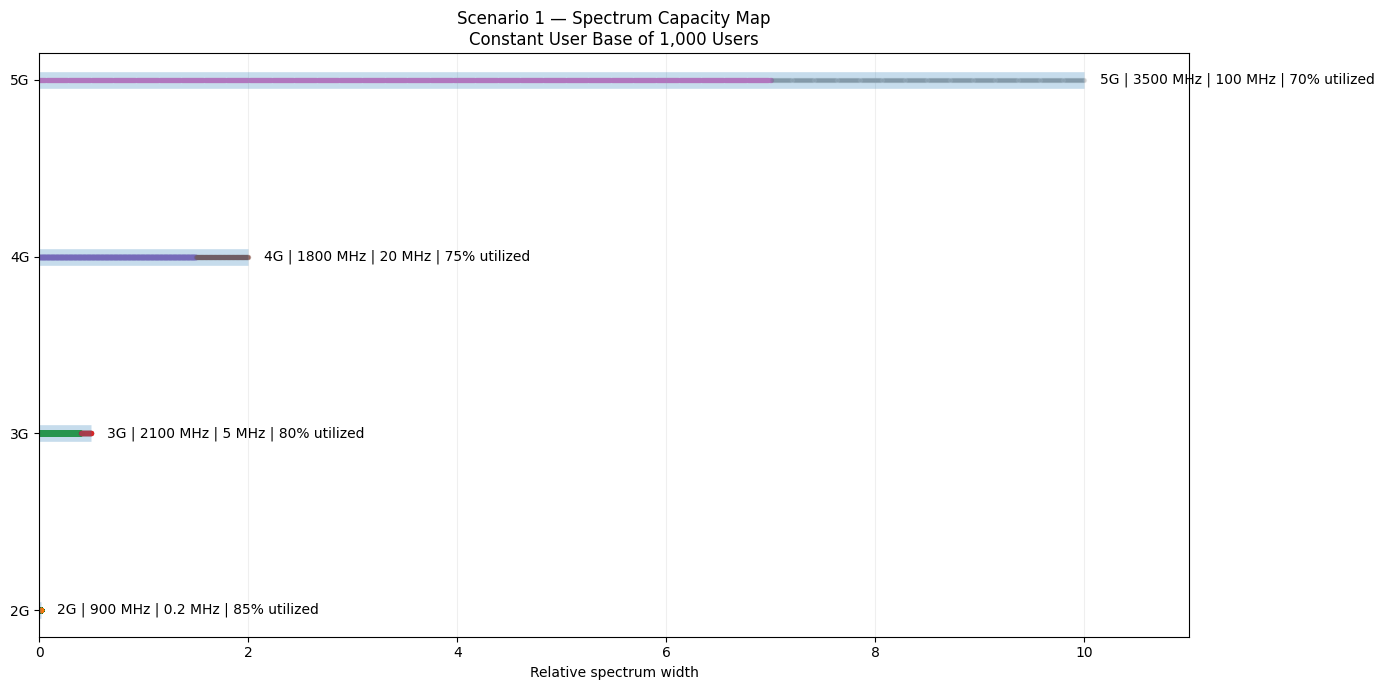

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

generations = ["2G", "3G", "4G", "5G"]

frequency = {
    "2G": 900,
    "3G": 2100,
    "4G": 1800,
    "5G": 3500
}

bandwidth = {
    "2G": 0.2,
    "3G": 5,
    "4G": 20,
    "5G": 100
}

resource_utilization = {
    "2G": 0.85,
    "3G": 0.80,
    "4G": 0.75,
    "5G": 0.70
}

# Spectral efficiency
spectral_efficiency = {
    "2G": 0.2,
    "3G": 1.0,
    "4G": 3.0,
    "5G": 5.0
}

# Average user requirement in Mbps
user_requirement = {
    "2G": 0.01,
    "3G": 0.05,
    "4G": 0.10,
    "5G": 0.20
}



capacity = {}

max_users = {}

for gen in generations:

    capacity[gen] = (
        bandwidth[gen]
        * spectral_efficiency[gen]
        * resource_utilization[gen]
    )

    max_users[gen] = int(
        capacity[gen] / user_requirement[gen]
    )



total_users = 1000

fig, ax = plt.subplots(figsize=(14, 7))

y_positions = np.arange(len(generations))

for i, gen in enumerate(generations):

    # Normalize bandwidth only for visualization
    normalized_bandwidth = (
        bandwidth[gen] / max(bandwidth.values())
    )

    spectrum_length = normalized_bandwidth * 10

    # Create 1000 users
    users = np.linspace(
        0,
        spectrum_length,
        total_users
    )

    # Resource utilization determines occupied region
    occupied = int(
        total_users * resource_utilization[gen]
    )

    # Draw spectrum line
    ax.hlines(
        i,
        0,
        spectrum_length,
        linewidth=12,
        alpha=0.25
    )

    # Draw users as individual points
    ax.scatter(
        users[:occupied],
        np.ones(occupied) * i,
        s=8,
        alpha=0.8
    )

    # Mark unused resources
    if occupied < total_users:

        ax.scatter(
            users[occupied:],
            np.ones(total_users - occupied) * i,
            s=8,
            alpha=0.15
        )

    # Add information
    ax.text(
        spectrum_length + 0.15,
        i,
        f"{gen} | {frequency[gen]} MHz | "
        f"{bandwidth[gen]} MHz | "
        f"{resource_utilization[gen]*100:.0f}% utilized",
        va="center",
        fontsize=10
    )


ax.set_yticks(y_positions)
ax.set_yticklabels(generations)

ax.set_xlabel(
    "Relative spectrum width"
)

ax.set_title(
    "Scenario 1 — Spectrum Capacity Map\n"
    "Constant User Base of 1,000 Users"
)

ax.set_xlim(0, 11)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

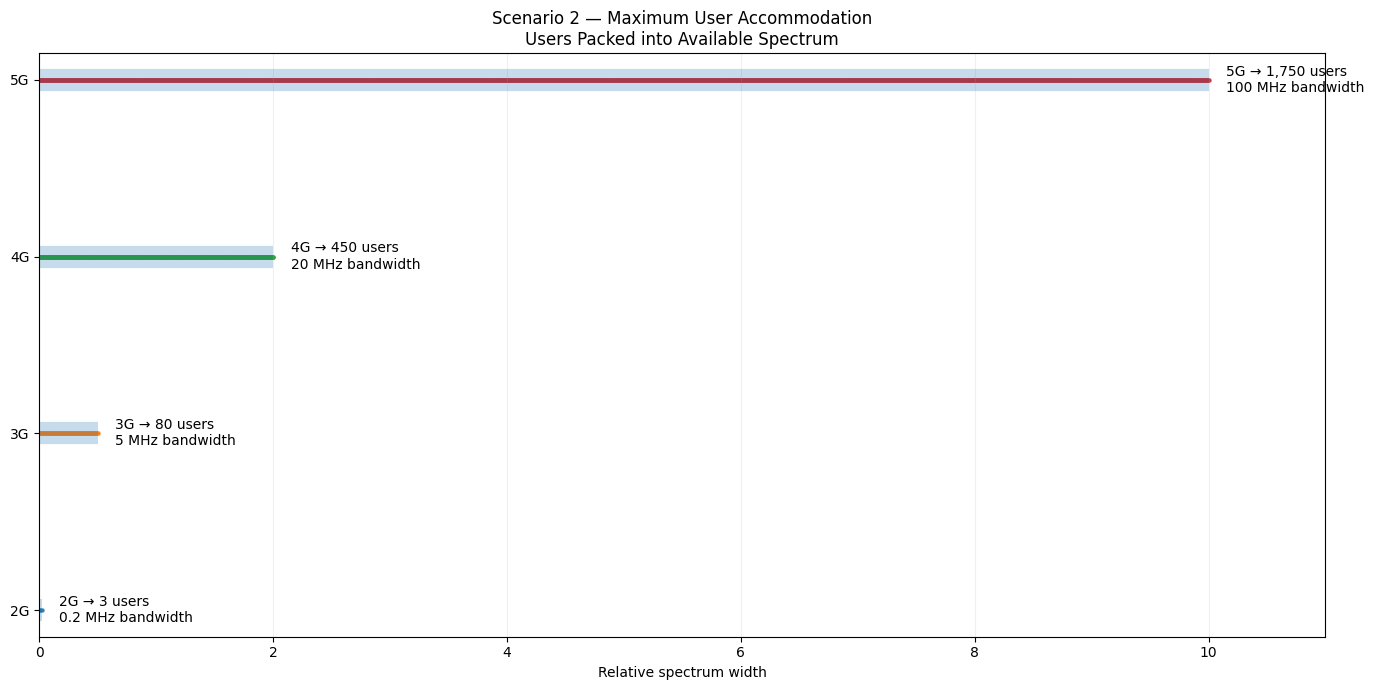

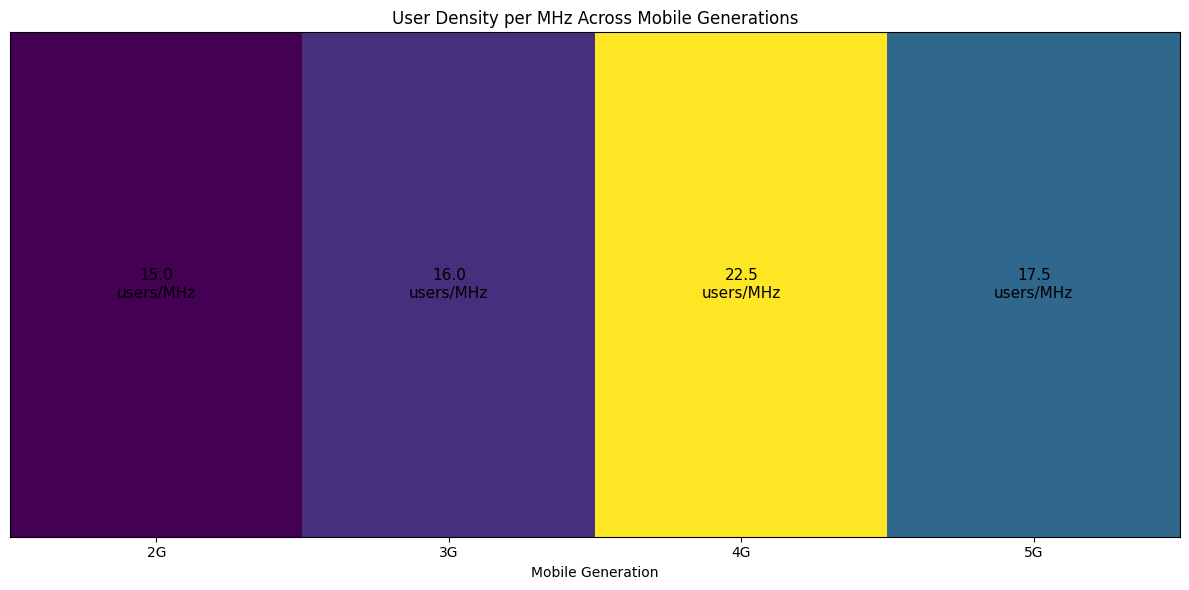

In [ ]:
# ============================================================
# SCENARIO 2
# MAXIMUM USER ACCOMMODATION
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

y_positions = np.arange(len(generations))

for i, gen in enumerate(generations):

    # Normalize bandwidth
    normalized_bandwidth = (
        bandwidth[gen] / max(bandwidth.values())
    )

    spectrum_length = normalized_bandwidth * 10

    # Maximum number of users
    users = max_users[gen]

    # Limit number of points for visualization
    display_users = min(users, 5000)

    user_positions = np.linspace(
        0,
        spectrum_length,
        display_users
    )

    # Spectrum
    ax.hlines(
        i,
        0,
        spectrum_length,
        linewidth=16,
        alpha=0.25
    )

    # Users
    ax.scatter(
        user_positions,
        np.ones(display_users) * i,
        s=5,
        alpha=0.8
    )

    # Label
    ax.text(
        spectrum_length + 0.15,
        i,
        f"{gen} → "
        f"{users:,} users\n"
        f"{bandwidth[gen]} MHz bandwidth",
        va="center",
        fontsize=10
    )


ax.set_yticks(y_positions)
ax.set_yticklabels(generations)

ax.set_xlabel(
    "Relative spectrum width"
)

ax.set_title(
    "Scenario 2 — Maximum User Accommodation\n"
    "Users Packed into Available Spectrum"
)

ax.set_xlim(0, 11)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# SCENARIO 2 — USER DENSITY MAP

fig, ax = plt.subplots(figsize=(12, 6))

density = []

for gen in generations:

    # Users per MHz
    users_per_mhz = (
        max_users[gen] /
        bandwidth[gen]
    )

    density.append(users_per_mhz)


# Create visual matrix
matrix = np.array(density).reshape(1, -1)

im = ax.imshow(
    matrix,
    aspect="auto"
)

ax.set_xticks(range(len(generations)))
ax.set_xticklabels(generations)

ax.set_yticks([])

ax.set_title(
    "User Density per MHz Across Mobile Generations"
)

ax.set_xlabel(
    "Mobile Generation"
)

# Add values
for i, value in enumerate(density):

    ax.text(
        i,
        0,
        f"{value:,.1f}\nusers/MHz",
        ha="center",
        va="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()